In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import MetaTrader5 as mt5
from ta.momentum import RSIIndicator

def carregar_dados(ticker, start="2000-01-01", end=None, timeframe="1d"):

    print(f"Baixando {ticker}...")

    df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)

    # corrige MultiIndex do Yahoo
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[
        [
            "Open",
            "High",
            "Low",
            "Close",
            "Volume"
        ]
    ]

    df.dropna(inplace=True)

    #print(
     #   f"{len(df)} pregões carregados"
    #)
    return df

def ret_medio_abs(window=40, classificacao="neutra_baixa", coluna="VolChange", n=35):

    candidatos = df.iloc[:-window]
    candidatos = candidatos[candidatos[coluna] == classificacao].copy()

    if len(candidatos) == 0:
        return pd.DataFrame([{
            "Periodos": window,
            "Mudança de Regime": classificacao,
            "N": 0,
            "Media_Absoluta": np.nan,
            "Media": np.nan,
            "Mediana": np.nan,
            "Maximo": np.nan,
            "Minimo": np.nan
        }])

    linhas = candidatos.sample(n=n, replace=True)

    pos = df.index.get_indexer(linhas.index)

    close_inicial = df.iloc[pos]["CloseReal"].to_numpy()
    close_futuro = df.iloc[pos + window]["CloseReal"].to_numpy()

    retornos = (close_futuro / close_inicial - 1) * 100

    return pd.DataFrame([{
        "Periodos": window,
        "Mudança de Regime": classificacao,
        "N": len(retornos),
        "Media_Absoluta": np.mean(np.abs(retornos)),
        "Media": np.mean(retornos),
        "Mediana": np.median(retornos),
        "Maximo": np.max(retornos),
        "Minimo": np.min(retornos)
    }])

In [2]:
mm = 120
df = carregar_dados(ticker="BTC-USD", start="2010-01-01", end=None)
df['CloseReal'] = df['Close']
# DISTANCIAS CANDLES STICK ==========================================
df["Dist_HL"] = (df["High"] - df["Low"])#.abs()
df["Dist_OC"] = (df["Open"] - df["Close"])#.abs()
df["Dist_HL_pct"] = (df["High"] - df["Low"]) / df["Close"] * 100
df["Dist_OC_pct"] = ((df["Open"] - df["Close"]) / df["Close"] * 100).rolling(60).mean()


#df["Dist_HL_pct"] = df["Dist_HL_pct"].rolling(90).mean()
#df["Dist_OC_pct"] = df["Dist_OC_pct"].rolling(90).mean()

# CLOSE PERCENTUAL ========================================
df["Close"] = np.log(df["Close"] / df["Close"].shift(1)).cumsum()

# RSI ======================================================
df["RSI"] = RSIIndicator(close=df["Close"], window=14).rsi()

# VOLATILIDADE ==============================================
df["VOL"] = (df["Close"].rolling(21).std() * np.sqrt(252))

# PERCENTIL VOL ==============================================
df["VOL_P80"] = df["VOL"].rolling(252).quantile(0.75)
df["VOL_P50"] = df["VOL"].rolling(252).quantile(0.50)
df["VOL_P20"] = df["VOL"].rolling(252).quantile(0.20)

# MEDIA MOVEL ==============================================
df["MM"] = df["Close"].rolling(mm).mean()

# NO TREND ==============================================
df["Dist_MM"] = (df["Close"] - df["MM"])
#df["Dist_MM"] = df["Dist_MM"].rolling(60).mean()
std = df["Dist_MM"].rolling(mm).std()

df["STD_1+"] = std
df["STD_1-"] = -std 
df["STD_2+"] = 2 * std
df["STD_2-"] = -2 * std
df["STD_3+"] = 3 * std
df["STD_3-"] = -3 * std
df["STD_4+"] = 4 * std
df["STD_4-"] = -4 * std

# CLASSIFICAR VOL =====================================
df["classVol"] = np.select(
    [
        df["VOL"] < df["VOL_P20"],
        df["VOL"] > df["VOL_P80"]
    ],
    [
        "baixa",
        "alta"
    ],
    default="neutra"
)

anterior = df["classVol"].shift(1)
atual = df["classVol"]

df["VolChange"] = np.select(
    [
        (anterior == "baixa") & (atual == "neutra"),
        (anterior == "neutra") & (atual == "alta"),
        (anterior == "alta") & (atual == "neutra"),
        (anterior == "neutra") & (atual == "baixa")
    ],
    [
        "baixa_neutra",
        "neutra_alta",
        "alta_neutra",
        "neutra_baixa"
    ],
    default="-"
)


# ================================
# DESVIO PADRÃO

df["classDistMM"] = np.select(
    [
        df["Dist_MM"] < df["STD_4-"],
        df["Dist_MM"] < df["STD_3-"],
        df["Dist_MM"] < df["STD_2-"],
        df["Dist_MM"] < df["STD_1-"],
        df["Dist_MM"] > df["STD_4+"],
        df["Dist_MM"] > df["STD_3+"],
        df["Dist_MM"] > df["STD_2+"],
        df["Dist_MM"] > df["STD_1+"]
    ],
    [
        "baixa_4std",
        "baixa_3std",
        "baixa_2std",
        "baixa_1std",
        "alta_4std",
        "alta_3std",
        "alta_2std",
        "alta_1std"
    ],
    default="neutra"
)

anterior = df["classDistMM"].shift(1)
atual = df["classDistMM"]

df["DistMMChange"] = np.select(
    [
        (anterior == "baixa_4std") & (atual == "baixa_3std"),
        (anterior == "baixa_3std") & (atual == "baixa_2std"),
        (anterior == "baixa_2std") & (atual == "baixa_1std"),
        (anterior == "baixa_1std") & (atual == "neutra"),

        (anterior == "neutra") & (atual == "alta_1std"),
        (anterior == "alta_1std") & (atual == "alta_2std"),
        (anterior == "alta_2std") & (atual == "alta_3std"),
        (anterior == "alta_3std") & (atual == "alta_4std"),

        (anterior == "alta_4std") & (atual == "alta_3std"),
        (anterior == "alta_3std") & (atual == "alta_2std"),
        (anterior == "alta_2std") & (atual == "alta_1std"),
        (anterior == "alta_1std") & (atual == "neutra"),

        (anterior == "neutra") & (atual == "baixa_1std"),
        (anterior == "baixa_1std") & (atual == "baixa_2std"),
        (anterior == "baixa_2std") & (atual == "baixa_3std"),
        (anterior == "baixa_3std") & (atual == "baixa_4std")
    ],
    [
        "baixa_4std_baixa_3std",
        "baixa_3std_baixa_2std",
        "baixa_2std_baixa_1std",
        "baixa_1std_neutra",

        "neutra_alta_1std",
        "alta_1std_alta_2std",
        "alta_2std_alta_3std",
        "alta_3std_alta_4std",

        "alta_4std_alta_3std",
        "alta_3std_alta_2std",
        "alta_2std_alta_1std",
        "alta_1std_neutra",

        "neutra_baixa_1std",
        "baixa_1std_baixa_2std",
        "baixa_2std_baixa_3std",
        "baixa_3std_baixa_4std"
    ],
    default="-"
)

Baixando BTC-USD...


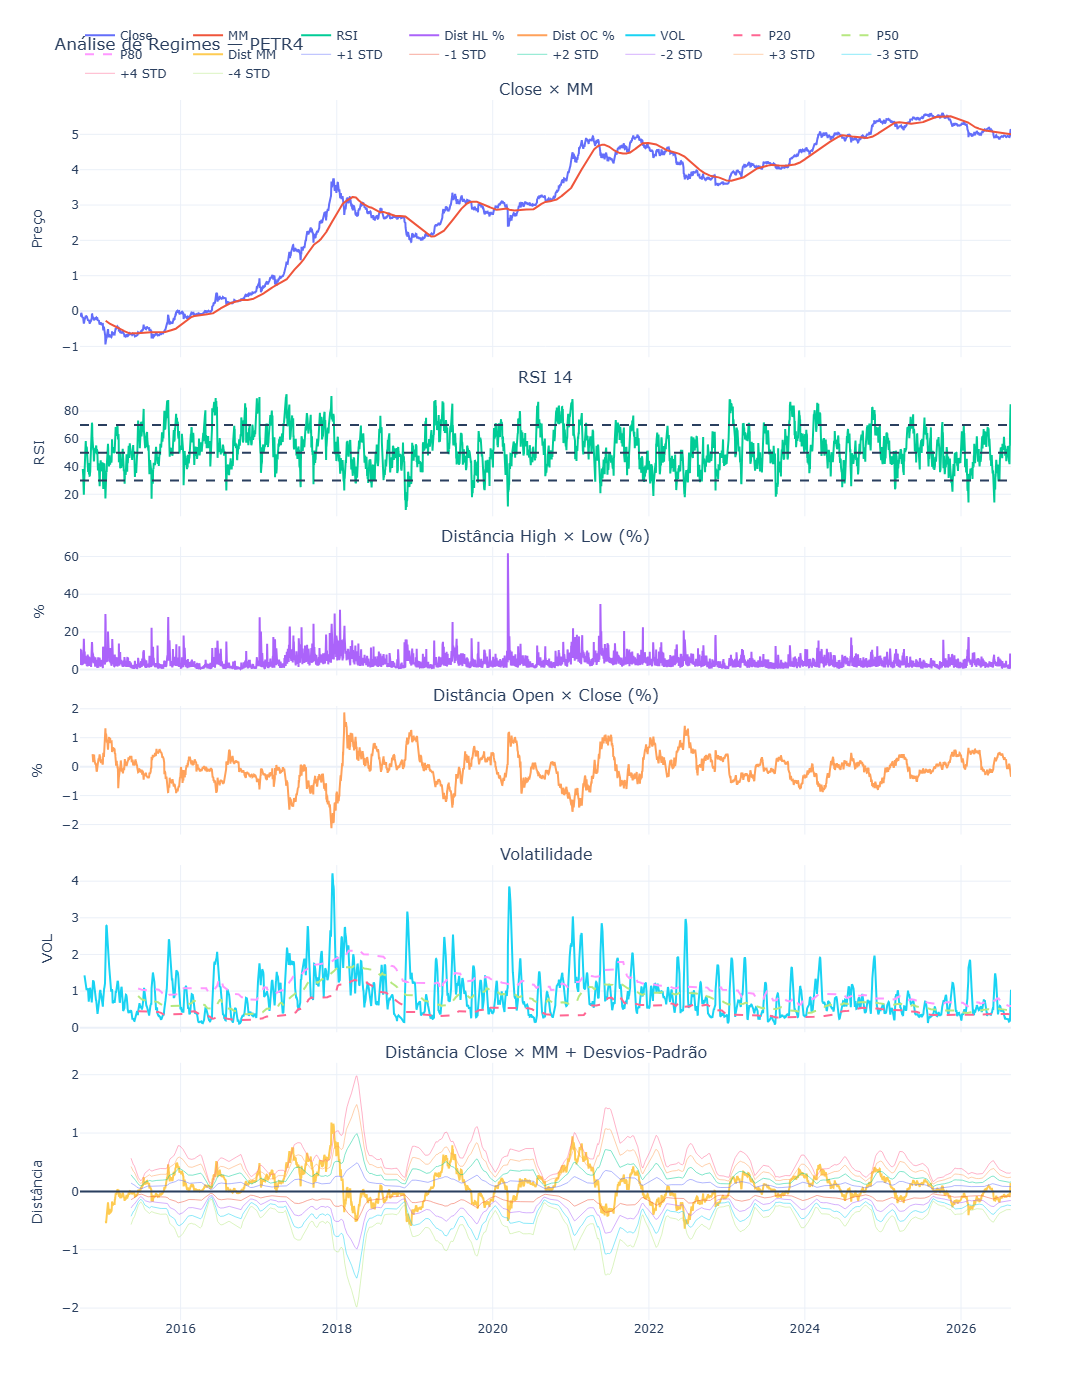

In [3]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=6,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.025,
    row_heights=[2, 1, 1, 1, 1.3, 2],
    subplot_titles=[
        "Close × MM",
        "RSI 14",
        "Distância High × Low (%)",
        "Distância Open × Close (%)",
        "Volatilidade",
        "Distância Close × MM + Desvios-Padrão"
    ]
)

# =========================================================
# PLOT 1 — CLOSE + MM
# =========================================================

fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        name="Close",
        mode="lines"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["MM"],
        name="MM",
        mode="lines"
    ),
    row=1, col=1
)

# =========================================================
# PLOT 2 — RSI
# =========================================================

fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["RSI"],
        name="RSI",
        mode="lines"
    ),
    row=2, col=1
)

for nivel in [70, 50, 30]:
    fig.add_hline(
        y=nivel,
        line_dash="dash",
        row=2,
        col=1
    )

# =========================================================
# PLOT 3 — DIST HL
# =========================================================

fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Dist_HL_pct"],
        name="Dist HL %",
        mode="lines"
    ),
    row=3, col=1
)

# =========================================================
# PLOT 4 — DIST OC
# =========================================================

fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Dist_OC_pct"],
        name="Dist OC %",
        mode="lines"
    ),
    row=4, col=1
)

# =========================================================
# PLOT 5 — VOLATILIDADE
# =========================================================

for coluna, nome in [
    ("VOL", "VOL"),
    ("VOL_P20", "P20"),
    ("VOL_P50", "P50"),
    ("VOL_P80", "P80")
]:
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df[coluna],
            name=nome,
            mode="lines",
            line=dict(
                dash="solid" if coluna == "VOL" else "dash"
            )
        ),
        row=5, col=1
    )

# =========================================================
# PLOT 6 — DIST MM + STD
# =========================================================

fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Dist_MM"],
        name="Dist MM",
        mode="lines"
    ),
    row=6, col=1
)

for i in range(1, 5):

    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df[f"STD_{i}+"],
            name=f"+{i} STD",
            mode="lines",
            line=dict(width=0.5)
        ),
        row=6, col=1
    )

    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df[f"STD_{i}-"],
            name=f"-{i} STD",
            mode="lines",
            line=dict(width=0.5)
        ),
        row=6, col=1
    )

fig.add_hline(
    y=0,
    row=6,
    col=1
)

# =========================================================
# LAYOUT
# =========================================================

fig.update_layout(
    height=1400,
    template="plotly_white",
    hovermode="x unified",
    title="Análise de Regimes — PETR4",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.01,
        xanchor="left",
        x=0
    )
)

fig.update_yaxes(title="Preço", row=1, col=1)
fig.update_yaxes(title="RSI", row=2, col=1)
fig.update_yaxes(title="%", row=3, col=1)
fig.update_yaxes(title="%", row=4, col=1)
fig.update_yaxes(title="VOL", row=5, col=1)
fig.update_yaxes(title="Distância", row=6, col=1)

fig.show()

In [4]:
janela = 10
col_var1 = "VolChange"
classificacao0 = "-"
classificacao1 = "baixa_neutra"
classificacao2 = "neutra_alta"
classificacao3 = "alta_neutra"
classificacao4 = "neutra_baixa"

col_var2 = 'classVol'
classificacao5 = "baixa"
classificacao6 = "neutra"
classificacao7 = "alta"

resultados = pd.concat([
    ret_medio_abs(janela, classificacao0, col_var1),
    ret_medio_abs(janela, classificacao1, col_var1),
    ret_medio_abs(janela, classificacao2, col_var1),
    ret_medio_abs(janela,classificacao3, col_var1),
    ret_medio_abs(janela,classificacao4, col_var1),
    
    ret_medio_abs(janela,classificacao5, col_var2), # OUTRA COLUNA
    ret_medio_abs(janela,classificacao6, col_var2), # OUTRA COLUNA
    ret_medio_abs(janela,classificacao7, col_var2) # OUTRA COLUNA
], ignore_index=True)

display(resultados)

,Periodos,Mudança de Regime,N,Media_Absoluta,Media,Mediana,Maximo,Minimo
0,10,-,35,7.731804,1.185087,-1.090378,25.785906,-16.537348
1,10,baixa_neutra,35,6.063890,-1.752077,-0.151183,14.678019,-25.317446
2,10,neutra_alta,35,8.734173,6.164499,5.080682,43.231413,-10.822963
3,10,alta_neutra,35,6.941249,-0.319732,0.234709,36.176468,-35.337638
4,10,neutra_baixa,35,7.006138,0.221617,-0.936852,28.842298,-26.019723
5,10,baixa,35,8.332849,2.069740,0.019994,24.880084,-25.562776
6,10,neutra,35,5.781953,-1.017457,-1.095579,12.735384,-18.128109
7,10,alta,35,9.551802,6.005106,4.112151,38.111281,-11.784049


In [5]:
resultado1 = pd.DataFrame({
    "Ocorrencias": df["VolChange"].value_counts(),
    "Percentual": df["VolChange"].value_counts(normalize=True) * 100
}).reindex(["baixa_neutra", "neutra_alta", "alta_neutra", "neutra_baixa", "-"])

resultado1["Percentual"] = resultado1["Percentual"].round(2)

display(resultado1)
###########################################
resultado = pd.DataFrame({
    "Ocorrencias": df["classVol"].value_counts(),
    "Percentual": df["classVol"].value_counts(normalize=True) * 100
}).reindex(["baixa", "neutra", "alta"])

resultado["Percentual"] = resultado["Percentual"].round(2)

display(resultado)

,Ocorrencias,Percentual
VolChange,,
baixa_neutra,78,1.79
neutra_alta,69,1.58
alta_neutra,68,1.56
neutra_baixa,78,1.79
-,4065,93.28


,Ocorrencias,Percentual
classVol,,
baixa,933,21.41
neutra,2407,55.23
alta,1018,23.36


In [6]:
resultado1 = pd.DataFrame({
    "Ocorrencias": df["DistMMChange"].value_counts(),
    "Percentual": df["DistMMChange"].value_counts(normalize=True) * 100
}).reindex([
    "baixa_4std_baixa_3std",
    "baixa_3std_baixa_2std",
    "baixa_2std_baixa_1std",
    "baixa_1std_neutra",
    "neutra_alta_1std",
    "alta_1std_alta_2std",
    "alta_2std_alta_3std",
    "alta_3std_alta_4std",
    "alta_4std_alta_3std",
    "alta_3std_alta_2std",
    "alta_2std_alta_1std",
    "alta_1std_neutra",
    "neutra_baixa_1std",
    "baixa_1std_baixa_2std",
    "baixa_2std_baixa_3std",
    "baixa_3std_baixa_4std",
    "-"
])

resultado1["Percentual"] = resultado1["Percentual"].round(2)

display(resultado1)

###########################################

resultado = pd.DataFrame({
    "Ocorrencias": df["classDistMM"].value_counts(),
    "Percentual": df["classDistMM"].value_counts(normalize=True) * 100
}).reindex([
    "baixa_4std",
    "baixa_3std",
    "baixa_2std",
    "baixa_1std",
    "neutra",
    "alta_1std",
    "alta_2std",
    "alta_3std",
    "alta_4std"
])

resultado["Percentual"] = resultado["Percentual"].round(2)

display(resultado)

,Ocorrencias,Percentual
DistMMChange,,
baixa_4std_baixa_3std,5,0.11
baixa_3std_baixa_2std,7,0.16
baixa_2std_baixa_1std,27,0.62
baixa_1std_neutra,72,1.65
neutra_alta_1std,60,1.38
alta_1std_alta_2std,57,1.31
alta_2std_alta_3std,42,0.96
alta_3std_alta_4std,27,0.62
alta_4std_alta_3std,27,0.62


,Ocorrencias,Percentual
classDistMM,,
baixa_4std,16,0.37
baixa_3std,56,1.28
baixa_2std,129,2.96
baixa_1std,519,11.91
neutra,1969,45.18
alta_1std,795,18.24
alta_2std,453,10.39
alta_3std,271,6.22
alta_4std,150,3.44


In [9]:
''' # VolChange
    ret_medio_abs(janela, "-", "VolChange"),
    ret_medio_abs(janela, "baixa_neutra", "VolChange"),
    ret_medio_abs(janela, "neutra_alta", "VolChange"),
    ret_medio_abs(janela, "alta_neutra", "VolChange"),
    ret_medio_abs(janela, "neutra_baixa", "VolChange"),

    # classVol
    ret_medio_abs(janela, "baixa", "classVol"),
    ret_medio_abs(janela, "neutra", "classVol"),
    ret_medio_abs(janela, "alta", "classVol"),'''
janela = 15

resultados = pd.concat([

    ret_medio_abs(janela, "baixa_4std_baixa_3std", "DistMMChange"),
    ret_medio_abs(janela, "baixa_3std_baixa_2std", "DistMMChange"),
    ret_medio_abs(janela, "baixa_2std_baixa_1std", "DistMMChange"),
    ret_medio_abs(janela, "baixa_1std_neutra", "DistMMChange"),

    ret_medio_abs(janela, "neutra_alta_1std", "DistMMChange"),
    ret_medio_abs(janela, "alta_1std_alta_2std", "DistMMChange"),
    ret_medio_abs(janela, "alta_2std_alta_3std", "DistMMChange"),
    ret_medio_abs(janela, "alta_3std_alta_4std", "DistMMChange"),

    ret_medio_abs(janela, "alta_4std_alta_3std", "DistMMChange"),
    ret_medio_abs(janela, "alta_3std_alta_2std", "DistMMChange"),
    ret_medio_abs(janela, "alta_2std_alta_1std", "DistMMChange"),
    ret_medio_abs(janela, "alta_1std_neutra", "DistMMChange"),

    ret_medio_abs(janela, "neutra_baixa_1std", "DistMMChange"),
    ret_medio_abs(janela, "baixa_1std_baixa_2std", "DistMMChange"),
    ret_medio_abs(janela, "baixa_2std_baixa_3std", "DistMMChange"),
    ret_medio_abs(janela, "baixa_3std_baixa_4std", "DistMMChange")

], ignore_index=True)

resultados["Ocorrencias"] = resultados["Mudança de Regime"].map(
    df["DistMMChange"].value_counts()
).fillna(0).astype(int)

display(resultados)

,Periodos,Mudança de Regime,N,Media_Absoluta,Media,Mediana,Maximo,Minimo,Ocorrencias
0,15,baixa_4std_baixa_3std,35,9.409831,-9.409831,-9.469037,-1.566708,-22.167009,5
1,15,baixa_3std_baixa_2std,35,6.346245,6.346245,6.801409,12.194870,1.698175,7
2,15,baixa_2std_baixa_1std,35,7.402601,-1.629882,-0.381536,9.989034,-33.981020,27
3,15,baixa_1std_neutra,35,8.125610,3.329823,0.686628,27.367176,-13.520773,72
4,15,neutra_alta_1std,35,7.543681,1.890871,-1.128563,28.104583,-15.345733,60
5,15,alta_1std_alta_2std,35,9.353227,4.624709,3.536837,41.949181,-18.167314,57
6,15,alta_2std_alta_3std,35,14.506231,3.795889,-0.146354,53.347279,-25.992139,42
7,15,alta_3std_alta_4std,35,13.537322,5.411490,5.522491,29.267652,-22.139980,27
8,15,alta_4std_alta_3std,35,11.163645,5.099312,5.384802,45.085764,-19.787002,27
9,15,alta_3std_alta_2std,35,7.928847,0.875508,0.812527,27.647760,-12.889622,42


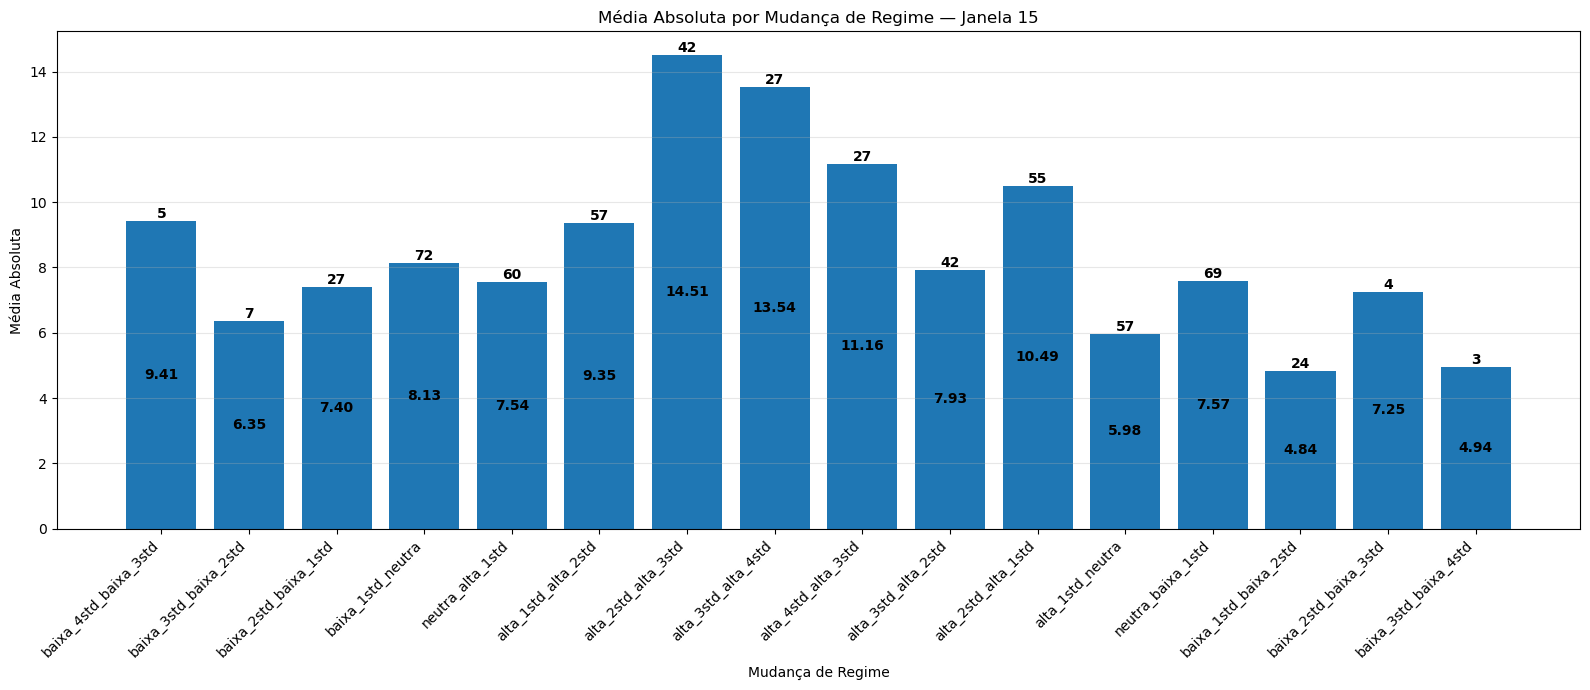

In [10]:
# ============================================================
# GRÁFICO
# ============================================================

plt.figure(figsize=(16, 7))

barras = plt.bar(
    resultados["Mudança de Regime"],
    resultados["Media_Absoluta"]
)

for barra, valor, n in zip(
    barras,
    resultados["Media_Absoluta"],
    resultados["Ocorrencias"]
):
    x = barra.get_x() + barra.get_width() / 2
    altura = barra.get_height()

    # Valor da Média Absoluta no meio da barra
    plt.text(
        x,
        altura / 2,
        f"{valor:.2f}",
        ha="center",
        va="center",
        fontweight="bold"
    )

    # Número de ocorrências no topo
    plt.text(
        x,
        altura,
        f"{n}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.xlabel("Mudança de Regime")
plt.ylabel("Média Absoluta")
plt.title(f"Média Absoluta por Mudança de Regime — Janela {janela}")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
janela = 30

resultados = pd.concat([
    # VolChange
    ret_medio_abs(janela, "-", "VolChange"),
    ret_medio_abs(janela, "baixa_neutra", "VolChange"),
    ret_medio_abs(janela, "neutra_alta", "VolChange"),
    ret_medio_abs(janela, "alta_neutra", "VolChange"),
    ret_medio_abs(janela, "neutra_baixa", "VolChange"),

    # classVol
    ret_medio_abs(janela, "baixa", "classVol"),
    ret_medio_abs(janela, "neutra", "classVol"),
    ret_medio_abs(janela, "alta", "classVol")
], ignore_index=True)

cont_volchange = df["VolChange"].value_counts()
cont_classvol = df["classVol"].value_counts()

resultados["Ocorrencias"] = [
    cont_volchange.get(x, 0) if x in ["-", "baixa_neutra", "neutra_alta", "alta_neutra", "neutra_baixa"]
    else cont_classvol.get(x, 0)
    for x in resultados["Mudança de Regime"]
]

display(resultados)

,Periodos,Mudança de Regime,N,Media_Absoluta,Media,Mediana,Maximo,Minimo,Ocorrencias
0,30,-,35,23.422139,9.683512,-2.867265,148.291932,-29.057248,4065
1,30,baixa_neutra,35,15.356350,3.817308,0.007262,40.880310,-33.102800,78
2,30,neutra_alta,35,18.984449,14.860497,12.032730,67.006698,-21.860036,69
3,30,alta_neutra,35,17.540741,5.350851,-2.716319,53.904947,-30.064966,68
4,30,neutra_baixa,35,13.540762,-2.267697,-0.662229,38.355188,-40.778862,78
5,30,baixa,35,18.688326,6.179850,5.177223,56.731752,-46.584871,933
6,30,neutra,35,16.776354,9.324410,4.338250,96.401473,-22.728186,2407
7,30,alta,35,14.047480,7.297817,3.919168,37.889783,-29.613868,1018


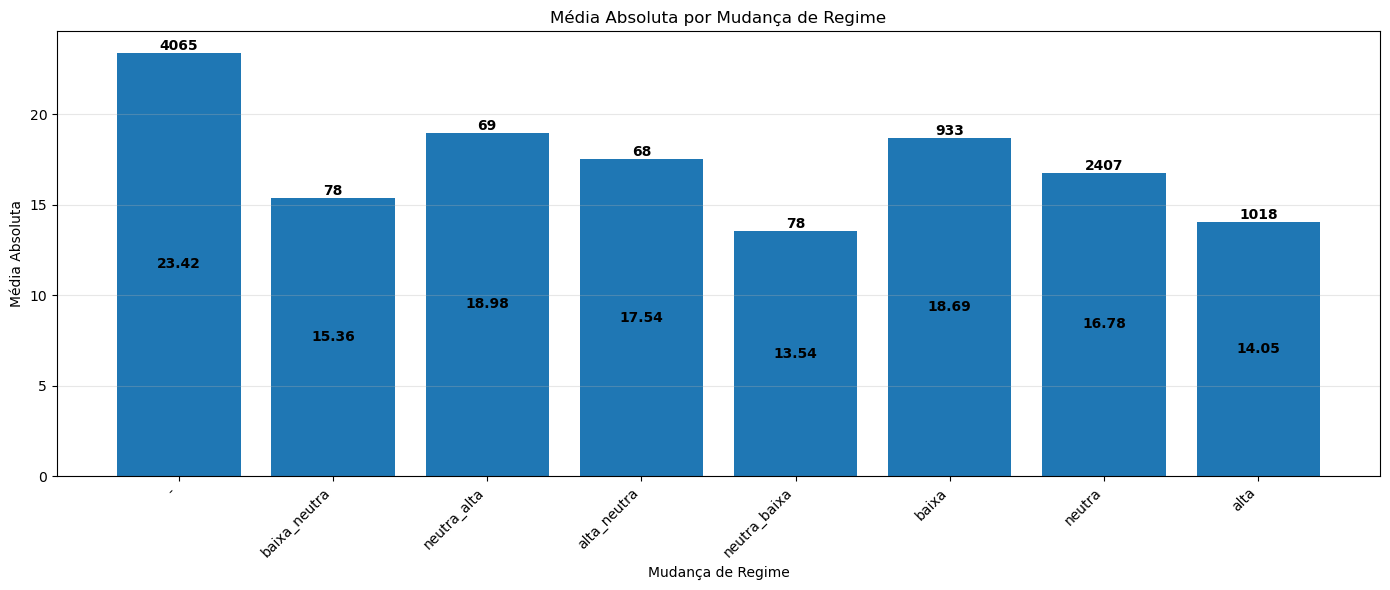

In [13]:
cont_volchange = df["VolChange"].value_counts()
cont_classvol = df["classVol"].value_counts()

ocorrencias = [
    cont_volchange.get(regime, 0)
    if regime in ["-", "baixa_neutra", "neutra_alta", "alta_neutra", "neutra_baixa"]
    else cont_classvol.get(regime, 0)
    for regime in resultados["Mudança de Regime"]
]

plt.figure(figsize=(14, 6))

barras = plt.bar(
    resultados["Mudança de Regime"],
    resultados["Media_Absoluta"]
)

for barra, valor, n in zip(
    barras,
    resultados["Media_Absoluta"],
    ocorrencias
):
    x = barra.get_x() + barra.get_width() / 2
    altura = barra.get_height()

    # Média Absoluta no meio da barra
    plt.text(
        x,
        altura / 2,
        f"{valor:.2f}",
        ha="center",
        va="center",
        fontweight="bold"
    )

    # Ocorrências no topo
    plt.text(
        x,
        altura,
        f"{n}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.xlabel("Mudança de Regime")
plt.ylabel("Média Absoluta")
plt.title("Média Absoluta por Mudança de Regime")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()